# Crop RecommendationClassifies the most suitable crop from soil nutrients and climate, comparingsix algorithms. The deployed model returns the top 3 crops by probability.Note: chilli accounts for 734 of 2,934 rows, so accuracy is optimistic for theother 22 crops — see [docs/models.md](../../docs/models.md).Data: `../data/all_crops_data.csv`

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ds = pd.read_csv('../data/all_crops_data.csv')
ds

,N,P,K,temperature,humidity,label
0,90,42,43,20.879744,82.002744,rice
1,85,58,41,21.770462,80.319644,rice
2,60,55,44,23.004459,82.320763,rice
3,74,35,40,26.491096,80.158363,rice
4,78,42,42,20.130175,81.604873,rice
...,...,...,...,...,...,...
2929,195,20,28,25.600000,36.100000,chilli
2930,193,20,28,25.600000,36.500000,chilli
2931,193,20,28,25.700000,36.700000,chilli
2932,194,20,28,25.800000,36.700000,chilli


In [3]:
ds = ds.rename(columns={'label': 'crop_type'})

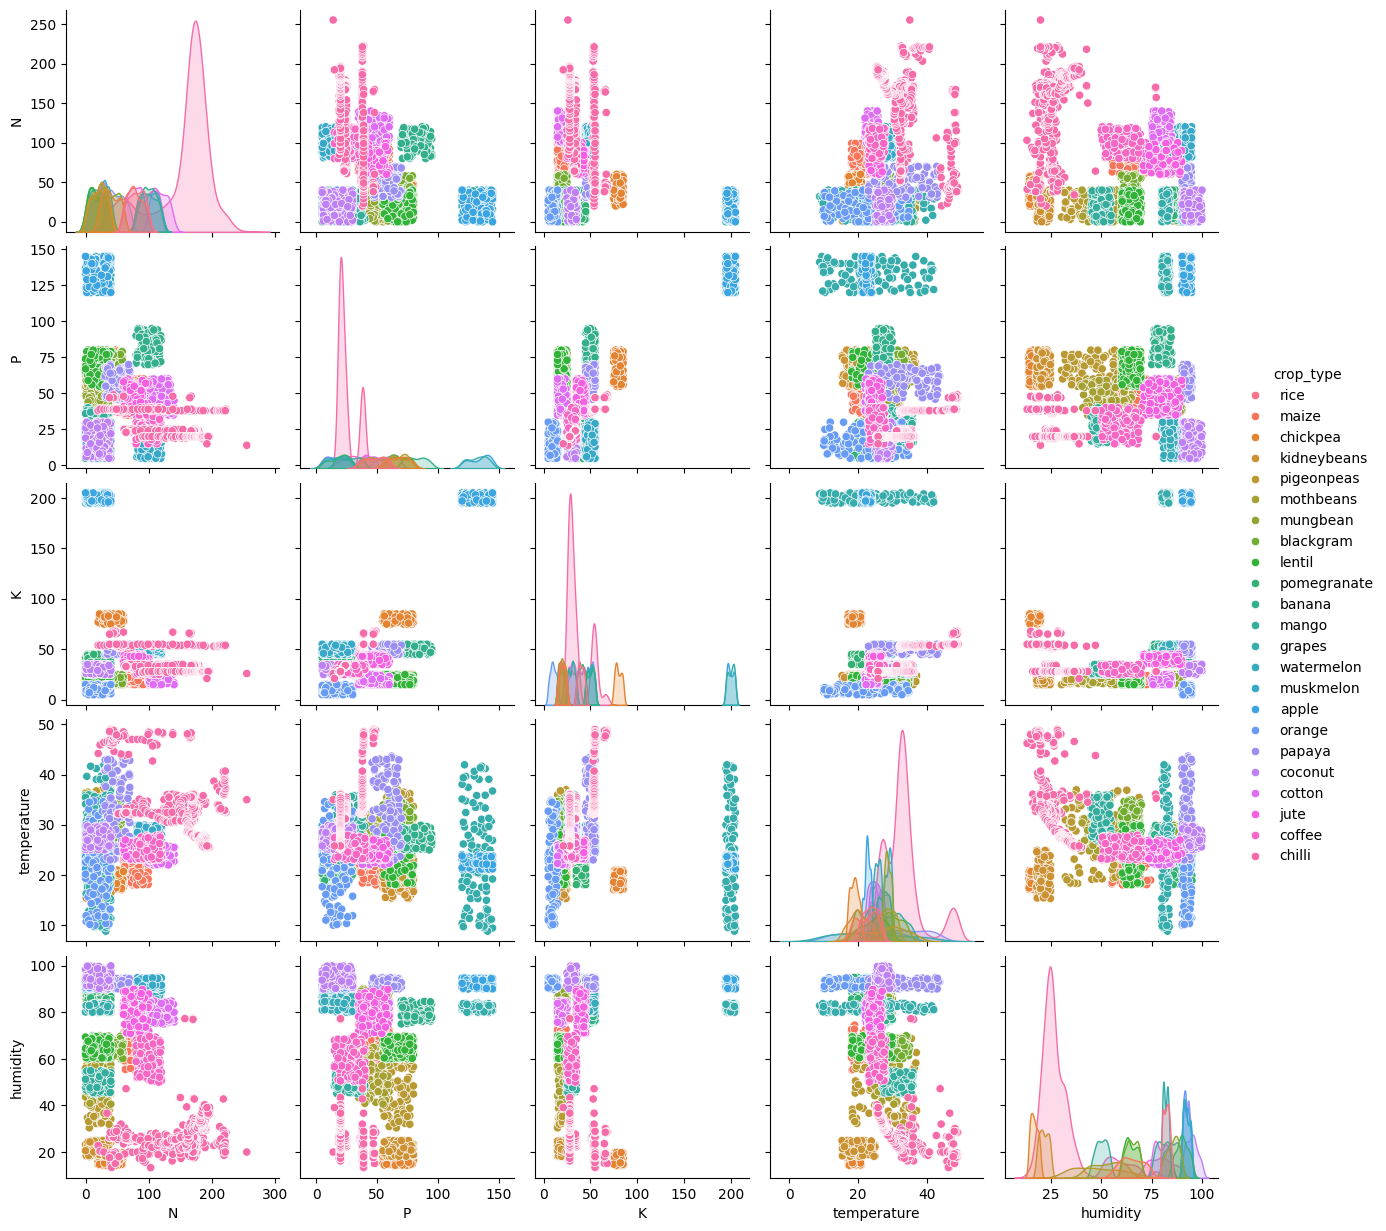

In [4]:
sns.pairplot(ds[['N', 'P', 'K', 'temperature', 'humidity', 'crop_type']], hue='crop_type')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

X = ds.drop('crop_type', axis=1)
y = ds['crop_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter = 1000)
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8415672913117547


In [7]:
from sklearn.svm import SVC

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svc = SVC(kernel = 'linear')
svc.fit(X_train_scaled, y_train)
y_pred = svc.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8841567291311755


In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9642248722316865


In [9]:
from sklearn.neighbors import KNeighborsClassifier

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9420783645655877


In [10]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9608177172061328


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

In [ ]:
def predict_top_3_crops(N, P, K, temperature, humidity):
    """Predicts the top 3 crops for given NPK values, temperature, and humidity."""

    input_data = np.array([[N, P, K, temperature, humidity]])

    # Get probabilities for each crop
    probabilities = rf.predict_proba(input_data)[0]

    # Get indices of top 3 crops
    top_3_indices = np.argsort(probabilities)[-3:][::-1]

    # Get the names and probabilities of the top 3 crops
    top_3_crops_with_probabilities = [
        (rf.classes_[i], probabilities[i] * 100) for i in top_3_indices
    ]

    # Print the top 3 crops with their probabilities
    print("Top 3 Recommended Crops:")
    for crop, probability in top_3_crops_with_probabilities:
        print(f"- {crop}: {probability:.2f}%")

    return top_3_crops_with_probabilities

N = 70
P = 35
K = 43
temperature = 20
humidity = 50

top_3_crops = predict_top_3_crops(N, P, K, temperature, humidity)

Top 3 Recommended Crops:
- coffee: 43.00%
- jute: 23.00%
- rice: 18.00%


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import joblib

joblib.dump(rf, "recommendation_model.joblib")